Cell 1 – Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


Cell 2 – Load data and quick view

In [3]:
# Load the dataset
df = pd.read_csv("Global_Pollution_Analysis.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


Cell 3 – Structure and missing values

In [4]:
# Dataset structure and missing values

df.info()
print("\nMissing values per column:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

Cell 4 – Separate numerical/categorical and impute

In [5]:
# Separate numerical and categorical columns

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# Impute numerical columns with median
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute categorical columns with most frequent value
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("\nMissing values after imputation:")
print(df.isna().sum())


Numerical columns: ['Year', 'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)', 'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)']
Categorical columns: ['Country']

Missing values after imputation:
Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64


Cell 5 – Outlier detection and treatment (IQR)

In [6]:
# Outlier detection and capping using IQR

outlier_cols = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "Energy_Recovered (in GWh)",
    "CO2_Emissions (in MT)",
    "Plastic_Waste_Produced (in tons)"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    out_before = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {out_before} potential outliers before capping")

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

df[outlier_cols].describe()


Air_Pollution_Index: 0 potential outliers before capping
Water_Pollution_Index: 0 potential outliers before capping
Soil_Pollution_Index: 0 potential outliers before capping
Industrial_Waste (in tons): 0 potential outliers before capping
Energy_Recovered (in GWh): 0 potential outliers before capping
CO2_Emissions (in MT): 0 potential outliers before capping
Plastic_Waste_Produced (in tons): 0 potential outliers before capping


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Plastic_Waste_Produced (in tons)
count,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000
mean,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,24492.893550
std,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,14421.356002
min,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,542.950000
25%,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,12843.882500
50%,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,24121.540000
75%,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,36516.232500
max,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49852.280000


Cell 6 – Pollution distributions

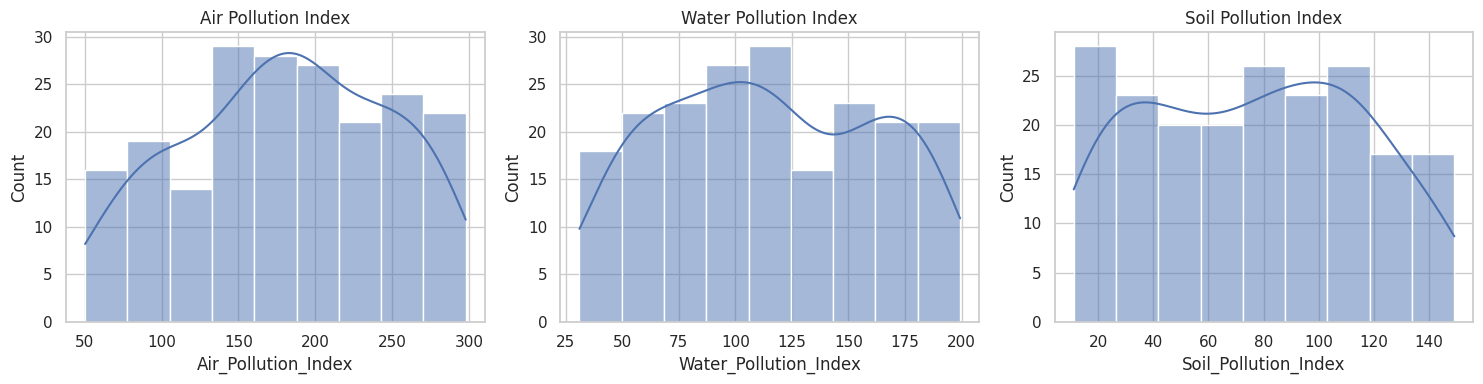

In [7]:
# Distributions of pollution indices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["Air_Pollution_Index"], kde=True, ax=axes[0])
axes[0].set_title("Air Pollution Index")

sns.histplot(df["Water_Pollution_Index"], kde=True, ax=axes[1])
axes[1].set_title("Water Pollution Index")

sns.histplot(df["Soil_Pollution_Index"], kde=True, ax=axes[2])
axes[2].set_title("Soil Pollution Index")

plt.tight_layout()
plt.show()


Cell 7 – Feature engineering (core features)

In [8]:
# Core feature engineering

# 1. Average pollution index across air, water, and soil
df["Avg_Pollution_Index"] = (
    df["Air_Pollution_Index"]
    + df["Water_Pollution_Index"]
    + df["Soil_Pollution_Index"]
) / 3.0

# 2. Energy recovered per capita (GWh -> MWh per person)
df["Energy_Recovered_Per_Capita_MWh"] = (
    df["Energy_Recovered (in GWh)"] * 1000
    / (df["Population (in millions)"] * 1_000_000)
)

# 3. CO2 emissions per capita (metric tons per person)
df["CO2_Per_Capita_MT"] = (
    df["CO2_Emissions (in MT)"]
    / (df["Population (in millions)"] * 1_000_000)
)

# 4. Pollution intensity per energy consumption
df["Pollution_per_Energy"] = df["Avg_Pollution_Index"] / (
    df["Energy_Consumption_Per_Capita (in MWh)"] + 1e-6
)

df.head()


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Avg_Pollution_Index,Energy_Recovered_Per_Capita_MWh,CO2_Per_Capita_MT,Pollution_per_Energy
0,Hungary,2005.0,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000,0.003746,1.255329e-07,11.914012
1,Singapore,2001.0,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333,0.003629,4.619308e-08,16.843846
2,Romania,2016.0,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000,0.003933,3.992127e-07,7.520152
3,Cook Islands,2018.0,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667,0.002141,1.314159e-07,188.610869
4,Djibouti,2008.0,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667,0.000216,8.004504e-08,11.117341


Cell 8 – Yearly pollution trend features

In [9]:
# Yearly and country-based pollution trend features

# Average pollution per (Country, Year) pair
df["Country_Year_Mean_Pollution"] = (
    df.groupby(["Country", "Year"])["Avg_Pollution_Index"]
      .transform("mean")
)

# Deviation from country-level long-term average
country_mean_pollution = (
    df.groupby("Country")["Avg_Pollution_Index"]
      .transform("mean")
)
df["Pollution_Deviation_From_Country_Mean"] = (
    df["Avg_Pollution_Index"] - country_mean_pollution
)

# Global yearly pollution level (time trend)
year_mean_pollution = (
    df.groupby("Year")["Avg_Pollution_Index"]
      .transform("mean")
)
df["Yearly_Global_Pollution_Trend"] = year_mean_pollution

df[["Country", "Year", "Avg_Pollution_Index",
    "Country_Year_Mean_Pollution",
    "Pollution_Deviation_From_Country_Mean",
    "Yearly_Global_Pollution_Trend"]].head()


,Country,Year,Avg_Pollution_Index,Country_Year_Mean_Pollution,Pollution_Deviation_From_Country_Mean,Yearly_Global_Pollution_Trend
0,Hungary,2005.0,149.640000,149.640000,0.000000,120.307778
1,Singapore,2001.0,88.093333,88.093333,0.000000,97.745926
2,Romania,2016.0,98.890000,98.890000,-8.041667,123.678333
3,Cook Islands,2018.0,147.116667,147.116667,0.000000,145.882667
4,Djibouti,2008.0,142.746667,142.746667,0.000000,124.135238


Cell 9 – Plot yearly global pollution trend

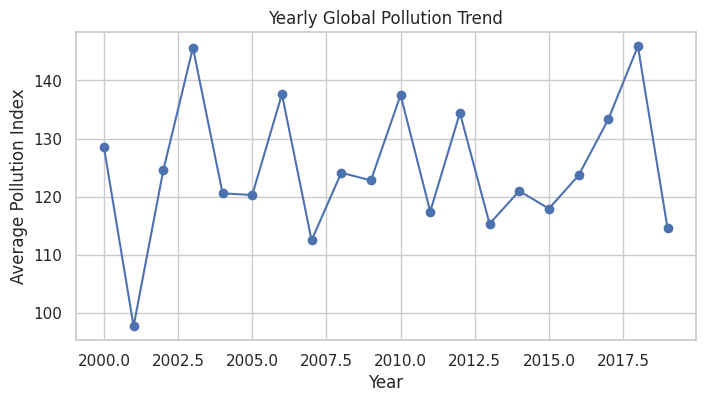

,Year,Avg_Pollution_Index
0,2000.0,128.530667
1,2001.0,97.745926
2,2002.0,124.541282
3,2003.0,145.623333
4,2004.0,120.599697


In [10]:
# Time-based analysis: yearly average pollution

yearly_trend = (
    df.groupby("Year")["Avg_Pollution_Index"]
      .mean()
      .reset_index()
      .sort_values("Year")
)

plt.figure(figsize=(8, 4))
plt.plot(yearly_trend["Year"], yearly_trend["Avg_Pollution_Index"], marker="o")
plt.xlabel("Year")
plt.ylabel("Average Pollution Index")
plt.title("Yearly Global Pollution Trend")
plt.grid(True)
plt.show()

yearly_trend.head()


Cell 10 – Create Pollution Severity labels

In [11]:
# Create pollution severity categories (Low, Medium, High) using quantiles

low_q = df["Avg_Pollution_Index"].quantile(0.33)
high_q = df["Avg_Pollution_Index"].quantile(0.66)

def pollution_category(x):
    if x <= low_q:
        return "Low"
    elif x <= high_q:
        return "Medium"
    else:
        return "High"

df["Pollution_Severity"] = df["Avg_Pollution_Index"].apply(pollution_category)

print("Pollution severity counts:")
print(df["Pollution_Severity"].value_counts())


Pollution severity counts:
Pollution_Severity
High      68
Low       66
Medium    66
Name: count, dtype: int64


Cell 11 – Visualize Pollution Severity distribution

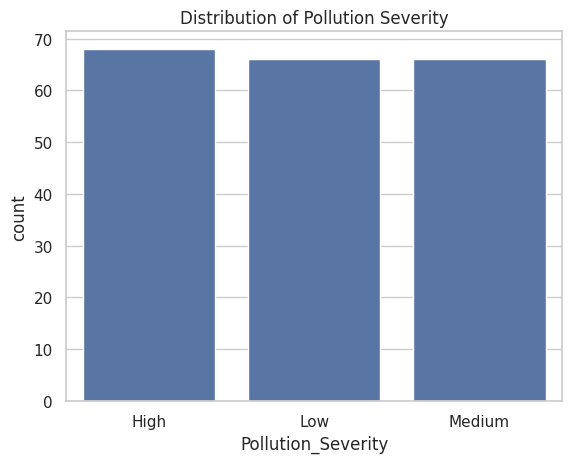

In [12]:
# Distribution of pollution severity

sns.countplot(x="Pollution_Severity", data=df)
plt.title("Distribution of Pollution Severity")
plt.show()


Cell 12 – Encode categorical variables

In [13]:
# Label encoding for categorical features and target

label_encoders = {}

for col in cat_cols + ["Pollution_Severity"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Encoded Pollution_Severity value counts:")
print(df["Pollution_Severity"].value_counts())


Encoded Pollution_Severity value counts:
Pollution_Severity
0    68
1    66
2    66
Name: count, dtype: int64


Cell 13 – Define features and scale

In [14]:
# Define feature matrix X and target y

target_col = "Pollution_Severity"
drop_cols = [target_col]

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[target_col]

print("Number of features:", len(feature_cols))
print("Feature columns:", feature_cols)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Number of features: 20
Feature columns: ['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)', 'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)', 'Avg_Pollution_Index', 'Energy_Recovered_Per_Capita_MWh', 'CO2_Per_Capita_MT', 'Pollution_per_Energy', 'Country_Year_Mean_Pollution', 'Pollution_Deviation_From_Country_Mean', 'Yearly_Global_Pollution_Trend']


Cell 14 – Train–test split

In [15]:
# Train-test split with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 160
Test size : 40


Cell 15 – Evaluation utilities

In [16]:
# Helper functions for evaluation and confusion matrices

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n===== {name} =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nClassification report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_score": f1
    }

def plot_cm(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} - Confusion Matrix")
    plt.show()


Cell 16 – Multinomial Naive Bayes


===== Multinomial Naive Bayes =====
Accuracy : 0.7
Precision: 0.6976270053475936
Recall   : 0.7
F1-score : 0.6945510752688172

Classification report:

              precision    recall  f1-score   support

           0       0.71      0.86      0.77        14
           1       0.75      0.69      0.72        13
           2       0.64      0.54      0.58        13

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.69        40
weighted avg       0.70      0.70      0.69        40



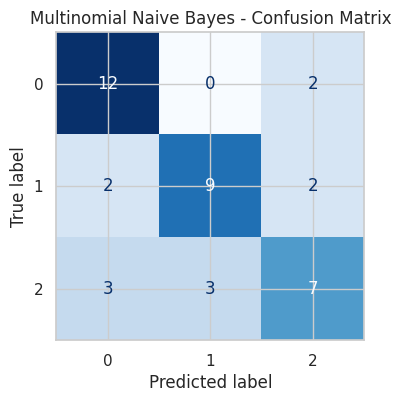

In [17]:
# Multinomial Naive Bayes classifier
# Uses MinMax-scaled features so data are non-negative

mms = MinMaxScaler()
X_train_nb = mms.fit_transform(X_train)
X_test_nb = mms.transform(X_test)

nb_clf = MultinomialNB()
nb_clf.fit(X_train_nb, y_train)

y_pred_nb = nb_clf.predict(X_test_nb)

results_nb = evaluate_model("Multinomial Naive Bayes", y_test, y_pred_nb)
plot_cm("Multinomial Naive Bayes", y_test, y_pred_nb)


Cell 17 – KNN with hyperparameter tuning

Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'distance'}
Best KNN CV accuracy: 0.85

===== K-Nearest Neighbors =====
Accuracy : 0.925
Precision: 0.9390625
Recall   : 0.925
F1-score : 0.9239880059970016

Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.77      0.87        13
           2       0.81      1.00      0.90        13

    accuracy                           0.93        40
   macro avg       0.94      0.92      0.92        40
weighted avg       0.94      0.93      0.92        40



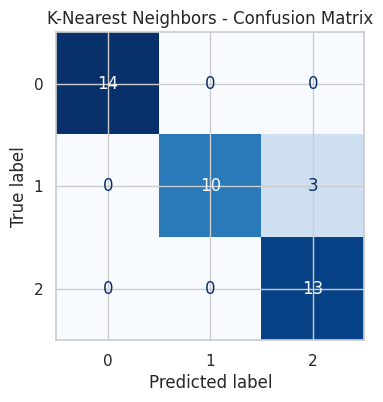

In [18]:
# K-Nearest Neighbors with GridSearchCV

knn = KNeighborsClassifier()

param_grid_knn = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

results_knn = evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)
plot_cm("K-Nearest Neighbors", y_test, y_pred_knn)


Cell 18 – Decision Tree with hyperparameter tuning

Best Decision Tree parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Best Decision Tree CV accuracy: 0.975

===== Decision Tree =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



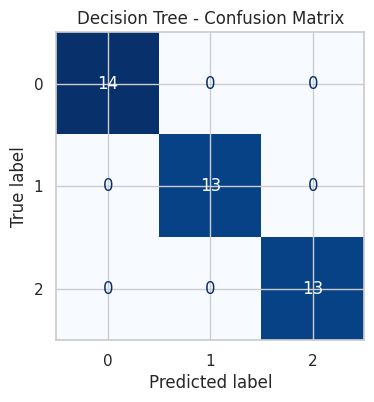

In [19]:
# Decision Tree classifier with GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "max_depth": [None, 3, 5, 7, 9, 11],
    "min_samples_split": [2, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Decision Tree parameters:", grid_dt.best_params_)
print("Best Decision Tree CV accuracy:", grid_dt.best_score_)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

results_dt = evaluate_model("Decision Tree", y_test, y_pred_dt)
plot_cm("Decision Tree", y_test, y_pred_dt)


Cell 19 – Model comparison plots

                     Model  Accuracy  Precision  Recall  F1_score
0  Multinomial Naive Bayes     0.700   0.697627   0.700  0.694551
1      K-Nearest Neighbors     0.925   0.939063   0.925  0.923988
2            Decision Tree     1.000   1.000000   1.000  1.000000


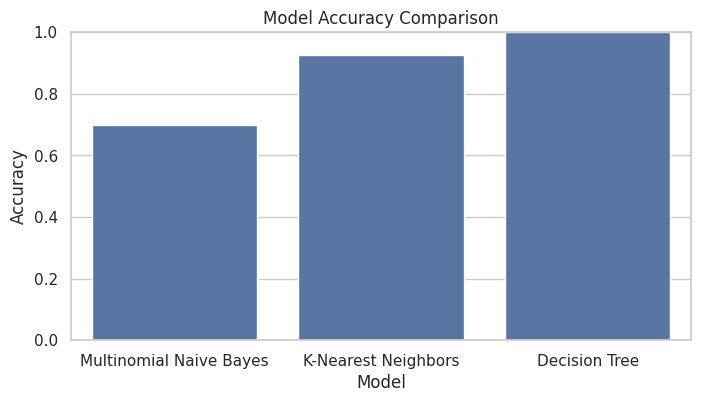

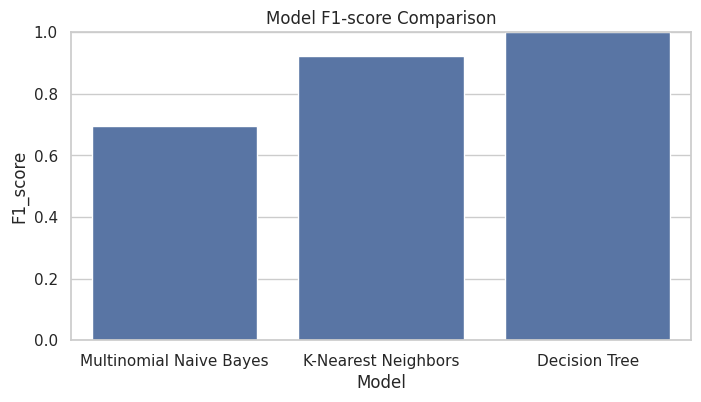

In [20]:
# Compare model performances

results_df = pd.DataFrame([results_nb, results_knn, results_dt])
print(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x="Model", y="F1_score", data=results_df)
plt.ylim(0, 1)
plt.title("Model F1-score Comparison")
plt.show()


Cell 20 – Correlation analysis (pollution vs energy)

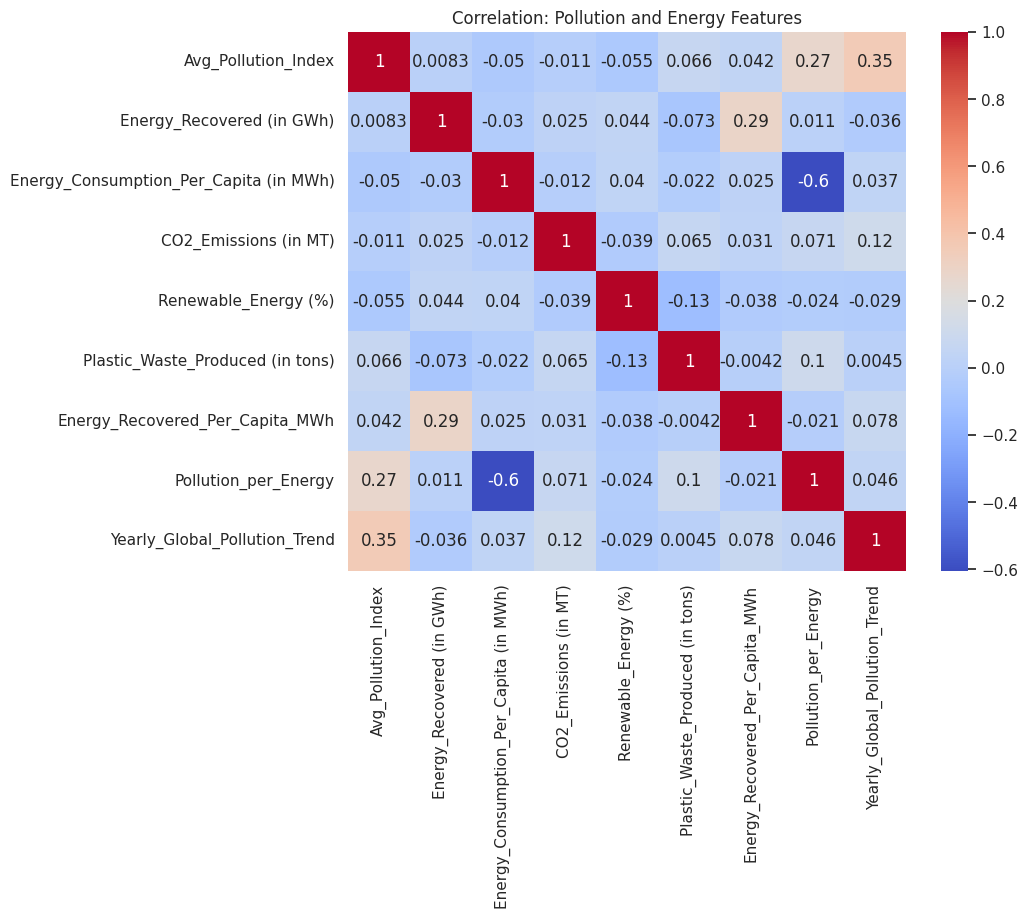

In [21]:
# Correlation between pollution and energy-related variables

corr_cols = [
    "Avg_Pollution_Index",
    "Energy_Recovered (in GWh)",
    "Energy_Consumption_Per_Capita (in MWh)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)",
    "Plastic_Waste_Produced (in tons)",
    "Energy_Recovered_Per_Capita_MWh",
    "Pollution_per_Energy",
    "Yearly_Global_Pollution_Trend"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation: Pollution and Energy Features")
plt.show()


Cell 21 – Aggregated summaries by Pollution Severity

In [22]:
# Summary statistics by pollution severity class

severity_summary = df.groupby("Pollution_Severity").agg({
    "Avg_Pollution_Index": "mean",
    "Energy_Recovered (in GWh)": "mean",
    "Energy_Consumption_Per_Capita (in MWh)": "mean",
    "Renewable_Energy (%)": "mean",
    "CO2_Emissions (in MT)": "mean",
    "Energy_Recovered_Per_Capita_MWh": "mean",
    "Pollution_per_Energy": "mean",
    "Yearly_Global_Pollution_Trend": "mean"
}).round(2)

severity_summary


,Avg_Pollution_Index,Energy_Recovered (in GWh),Energy_Consumption_Per_Capita (in MWh),Renewable_Energy (%),CO2_Emissions (in MT),Energy_Recovered_Per_Capita_MWh,Pollution_per_Energy,Yearly_Global_Pollution_Trend
Pollution_Severity,,,,,,,,
0,156.74,249.46,9.03,27.48,24.72,0.01,40.01,127.90
1,90.06,252.06,9.93,28.10,26.29,0.01,13.58,119.89
2,124.40,280.16,9.36,27.84,23.63,0.01,25.88,124.28
